In [1]:
library(ggplot2)
library(data.table)
theme_set(theme_bw())

# Source - https://stackoverflow.com/a
# Posted by dfrankow
# Retrieved 2026-01-16, License - CC BY-SA 3.0

options(repr.matrix.max.rows=600, repr.matrix.max.cols=200)

In [2]:
tools = c('singlem', 'sylph', 'singlem_dev')
publication_names = data.table(
    tool = tools,
    publication_name = c('SingleM', 'sylph', 'SingleM dev')
)
communities = paste0('marine',as.character(0))
d1 = data.table(expand.grid(tool = tools, community = communities))
d1[, tool2 := publication_names[tool, on = "tool", publication_name]]
# output_singlem/opal/GCA_022615805.1_genomic.opal_report
readit = function(tool, community){
    to_read = paste0('output_',tool,'/opal/',community,'.opal_report')
    return(fread(to_read))
}
d2 = d1[, readit(tool, community), by=list(tool,community, tool2)]

In [3]:
setnames(d2, c('tool', 'community', 'tool2', 'blah', 'rank', 'metric', 'sample', 'value'))
d3 = d2[blah != 'Gold standard', .(tool, community, rank, metric, value, tool2)]
d3[, rank := factor(rank, c('kingdom','phylum','class','order','family','genus','species'))]

In [4]:
fwrite(d3, 'accuracy_results.csv')# write out bc
fwrite(d3[metric == "Bray-curtis distance"], 'bray-curtis.csv', sep='\t')

In [5]:
s1 = dcast(d3, ...~metric, value.var='value')
s1[, c("tool", "tool2") := list(tool2, NULL)]

s1 = s1[order(rank, tool)]
fwrite(s1, 'opal_summary.csv', sep='\t')

Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`stat_boxplot()`).”


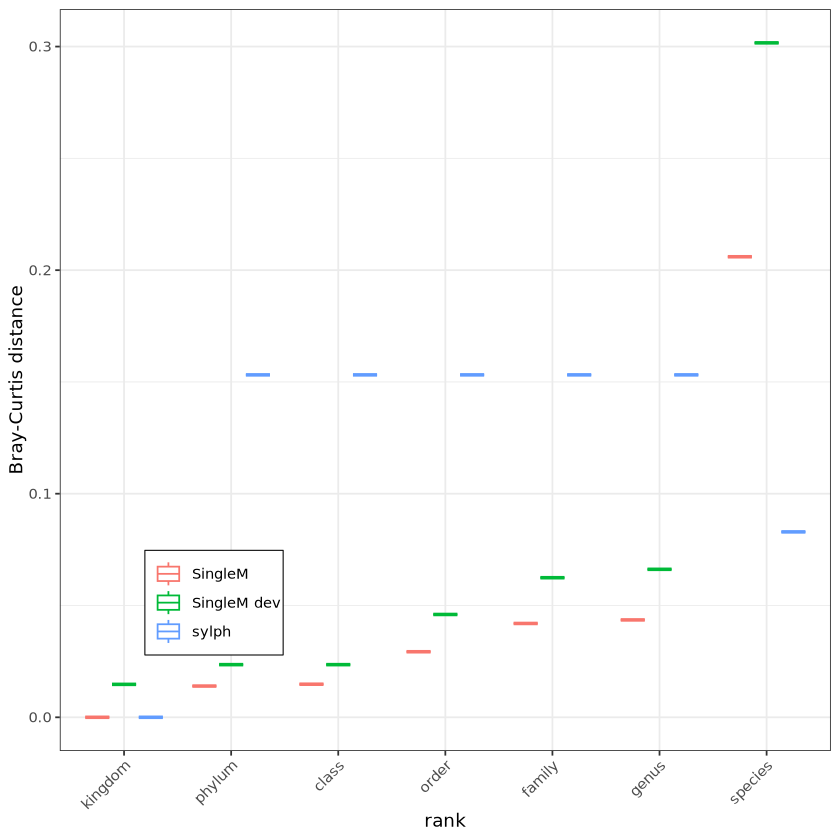

In [6]:
# Remove figure legend title, and put the legend in bottom left of plot, with a bounding box
ggplot(s1, aes(rank, `Bray-Curtis distance`, colour = tool)) +
   geom_boxplot() +
   scale_x_discrete(na.translate = FALSE) +
   theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
   theme(legend.title=element_blank()) +
   theme(legend.position=c(0.2,0.2)) +
   theme(legend.background = element_rect(colour = "black", linewidth = 0.3))

# Relationship between relative abundance and accuracy

In [7]:
truth_profiles = data.table(community=communities)
truth_profiles2 = truth_profiles[, fread(paste('truths/',community,'.condensed',sep='')), by=community]
truth_profiles2[, c("sample", "tool") := .(NULL, 'Gold standard')]

In [8]:
tool_profiles = data.table(expand.grid(tool = tools, community = communities))
tool_profiles2 = tool_profiles[
    ,
    fread(paste('output_',tool,'/',tool,'/',community,'.profile',sep='')),
    by=list(tool,community)
]
tool_profiles2[
    ,
    `:=`(sample = NULL,
         taxonomy = gsub('Root;','',gsub('; ',';',taxonomy)),
         tool = factor(publication_names[tool, on = "tool", publication_name]))
]

all_profiles = rbind(truth_profiles2, tool_profiles2)
all_profiles[, relabu := coverage / sum(coverage), by = list(community, tool)]
m = dcast(all_profiles, taxonomy + community ~ tool, value.var = c("relabu", "coverage"), fill = 0)
setnames(m, names(m), gsub("_", "__", names(m)))
setnames(m, c("relabu__Gold standard", "coverage__Gold standard"), c("true_relabu", "true_coverage"))

In [9]:
format_table <- function(m) {
    ra_cols <- grep("^relabu_|_relabu$", names(m), value = TRUE)
    mtmp = m[, which(!grepl("^coverage_|_coverage$", names(m))), with = FALSE]
    mtmp[
        ,
        c(ra_cols, "taxonomy") := c(
            lapply(.SD[, ra_cols, with = FALSE], scales::label_percent()),
            list(purrr::map_chr(strsplit(taxonomy, "; ?"), function(x) tail(x,1)))
        )
    ][]
}


In [10]:
# kingdom
format_table(m[grep("d__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";p__.*", "", taxonomy))])

community,taxonomy,true_relabu,relabu__SingleM,relabu__SingleM dev,relabu__sylph
<fct>,<chr>,<chr>,<chr>,<chr>,<chr>
marine0,d__Archaea,0%,0%,1%,0%
marine0,d__Bacteria,100%,100%,99%,100%


In [11]:
# phylum
format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";p__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";c__.*", "", taxonomy))])

community,taxonomy,true_relabu,relabu__SingleM,relabu__SingleM dev,relabu__sylph
<fct>,<chr>,<chr>,<chr>,<chr>,<chr>
marine0,p__Actinobacteriota,15.3%,15.42%,15.22%,0.0%
marine0,p__Bacteroidota,2.0%,2.08%,2.34%,2.4%
marine0,p__Elusimicrobiota,3.2%,2.59%,2.90%,4.0%
marine0,p__Firmicutes,10.4%,10.98%,10.92%,12.2%
marine0,p__Firmicutes_C,41.5%,41.34%,41.06%,49.3%
marine0,p__Proteobacteria,27.5%,26.24%,26.01%,32.2%
marine0,p__SAR324,0.0%,0.00%,0.07%,0.0%


In [12]:
# class
format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";c__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";o__.*", "", taxonomy))])

community,taxonomy,true_relabu,relabu__SingleM,relabu__SingleM dev,relabu__sylph
<fct>,<chr>,<chr>,<chr>,<chr>,<chr>
marine0,c__Actinomycetia,15.32%,15.42%,15.22%,0.00%
marine0,c__Bacteroidia,2.01%,2.08%,2.34%,2.39%
marine0,c__Elusimicrobia,3.18%,2.59%,2.90%,3.96%
marine0,c__Bacilli,10.44%,10.98%,10.92%,12.24%
marine0,c__Negativicutes,41.54%,41.34%,41.06%,49.27%
marine0,c__Alphaproteobacteria,3.65%,3.42%,3.61%,4.17%
marine0,c__Gammaproteobacteria,23.87%,22.67%,22.40%,27.98%
marine0,c__SAR324,0.00%,0.00%,0.07%,0.00%


In [13]:
# order
format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";o__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";f__.*", "", taxonomy))])

community,taxonomy,true_relabu,relabu__SingleM,relabu__SingleM dev,relabu__sylph
<fct>,<chr>,<chr>,<chr>,<chr>,<chr>
marine0,o__Actinomycetales,15.316%,12.418%,13.706%,0.000%
marine0,o__Mycobacteriales,0.000%,0.000%,0.116%,0.000%
marine0,o__Propionibacteriales,0.000%,0.000%,0.520%,0.000%
marine0,o__Streptomycetales,0.000%,0.000%,0.679%,0.000%
marine0,o__Streptosporangiales,0.000%,0.000%,0.202%,0.000%
marine0,o__Flavobacteriales,2.011%,2.082%,2.340%,2.386%
marine0,o__Elusimicrobiales,3.178%,2.595%,2.903%,3.960%
marine0,o__Erysipelotrichales,1.998%,2.067%,2.571%,2.363%
marine0,o__Lactobacillales,8.440%,8.078%,8.348%,9.872%


In [14]:
# family
format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";f__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";g__.*", "", taxonomy))])

community,taxonomy,true_relabu,relabu__SingleM,relabu__SingleM dev,relabu__sylph
<fct>,<chr>,<chr>,<chr>,<chr>,<chr>
marine0,f__Actinomycetaceae,0.000%,0.000%,0.332%,0.000%
marine0,f__Cellulomonadaceae,0.000%,0.000%,0.101%,0.000%
marine0,f__Dermatophilaceae,0.000%,0.000%,0.217%,0.000%
marine0,f__GCA-002748415,0.000%,0.000%,0.116%,0.000%
marine0,f__Kineosporiaceae,15.316%,10.834%,12.493%,0.000%
marine0,f__Micrococcaceae,0.000%,0.000%,0.448%,0.000%
marine0,f__Pseudonocardiaceae,0.000%,0.000%,0.116%,0.000%
marine0,f__Nocardioidaceae,0.000%,0.000%,0.520%,0.000%
marine0,f__Streptomycetaceae,0.000%,0.000%,0.679%,0.000%


In [15]:
# How well does genus level rescue some of the missing genomes? First need to remake the table with genus level, annoying since kraken profiles are filled, when the rest aren't.
format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";g__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";s__.*", "", taxonomy))])

community,taxonomy,true_relabu,relabu__SingleM,relabu__SingleM dev,relabu__sylph
<fct>,<chr>,<chr>,<chr>,<chr>,<chr>
marine0,g__Georgenia,0.000%,0.000%,0.116%,0.000%
marine0,g__Oceanitalea,0.000%,0.000%,0.217%,0.000%
marine0,g__Actinotalea,0.000%,0.000%,0.101%,0.000%
marine0,g__JADKGA01,0.000%,0.000%,0.217%,0.000%
marine0,g__GCA-002748415,0.000%,0.000%,0.116%,0.000%
marine0,g__JADJPO01,0.000%,0.000%,0.231%,0.000%
marine0,g__Kineosporia,15.316%,10.717%,12.262%,0.000%
marine0,g__Specibacter,0.000%,0.000%,0.448%,0.000%
marine0,g__Actinocrispum,0.000%,0.000%,0.116%,0.000%


In [16]:
# Species level
format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";s__", taxonomy)])

taxonomy,community,true_relabu,relabu__SingleM,relabu__SingleM dev,relabu__sylph
<chr>,<fct>,<chr>,<chr>,<chr>,<chr>
s__GCA-002748415 sp002748415,marine0,0.0000%,0.000%,0.116%,0.0000%
s__Kineosporia aurantiaca,marine0,0.0000%,0.000%,4.073%,0.0000%
s__Kineosporia sp018499875,marine0,0.0000%,2.668%,8.189%,0.0000%
s__Specibacter cremeus,marine0,0.0000%,0.000%,0.448%,0.0000%
s__Marmoricola_A sp902805865,marine0,0.0000%,0.000%,0.419%,0.0000%
s__Nocardioides_A sp018672315,marine0,0.0000%,0.000%,0.101%,0.0000%
s__Streptomyces sp018070565,marine0,0.0000%,0.000%,0.679%,0.0000%
s__Flavobacterium hydatis,marine0,2.0106%,2.082%,2.253%,2.3856%
s__Flavobacterium sp000813005,marine0,0.0000%,0.000%,0.087%,0.0000%


In [23]:
# read proportions
fix_names <- function(old)
    purrr::map_chr(strsplit(old, "; ?"), function(x) paste0(x, collapse = "; "))
bh = fread("debug/marine0.1_hits.tsv")
setnames(bh, names(bh)[!names(bh) %in% c("marker", "domain", "coverage")], fix_names)
obh = fread("debug/otu_hits.tsv")
setnames(obh, names(obh)[!names(obh) %in% c("marker", "domain", "coverage")], fix_names)

In [19]:
format_props <- function(m) {
    feat_cols <- names(m)[!names(m) %in% c("marker", "coverage")]
    m[
        ,
        c(list("marker" = marker, "coverage" = coverage),
          lapply(.SD, function(x) formatC(x, digits = 3))),
        .SDcols = -c("marker", "coverage")
    ]
}

In [20]:
# look at the 2% archaea
format_table(m[grepl("d__Archaea", taxonomy) & grepl(";g__", taxonomy)])

taxonomy,community,true_relabu,relabu__SingleM,relabu__SingleM dev,relabu__sylph
<chr>,<fct>,<chr>,<chr>,<chr>,<chr>
g__JAHLMS01,marine0,0%,0%,0.1%,0%
g__Methanocaldococcus,marine0,0%,0%,0.1%,0%
g__JAFCCC01,marine0,0%,0%,0.1%,0%
g__DTGE01,marine0,0%,0%,0.1%,0%
g__Sulfodiicoccus,marine0,0%,0%,1.2%,0%


In [21]:
arh = bh[rowSums(bh[, grep(value = TRUE, "d__Archaea", names(bh)), with = FALSE]) > 0]
arh_cols <- arh[, -c("marker", "domain", "coverage")][
    ,
    names(.SD),
    .SDcols = function(x) sum(x) > 0
]
format_props(arh[, c("marker", "domain", "coverage", arh_cols), with = FALSE])

marker,coverage,domain,Root; d__Archaea; p__Methanobacteriota_A; c__Methanococci; o__Methanococcales; f__Methanocaldococcaceae; g__Methanocaldococcus,Root; d__Archaea; p__Methanobacteriota_A; c__Methanococci; o__Methanococcales; f__Methanococcaceae; g__Methanotorris,Root; d__Archaea; p__Methanobacteriota_A; c__Methanococci; o__Methanococcales; f__Methanococcaceae; g__Methanococcus,Root; d__Archaea; p__Nanohaloarchaeota; c__Nanosalinia; o__Nanosalinales; f__JAFCCC01; g__JAFCCC01,Root; d__Archaea; p__Micrarchaeota; c__Micrarchaeia; o__Anstonellales; f__J096; g__J096,Root; d__Archaea; p__Nanoarchaeota; c__Nanoarchaeia; o__SCGC-AAA011-G17; f__PNOQ01; g__JABJPM01,Root; d__Archaea; p__Nanoarchaeota; c__Nanoarchaeia; o__SCGC-AAA011-G17; f__PNOQ01; g__JABHIB01,Root; d__Archaea; p__Thermoproteota; c__QMWL01; o__QMWL01; f__QMWL01; g__QMWL01,Root; d__Archaea; p__Thermoproteota; c__Bathyarchaeia; o__40CM-2-53-6; f__DTGE01; g__DTGE01,Root; d__Archaea; p__Aenigmatarchaeota; c__Aenigmatarchaeia; o__Aenigmatarchaeales; f__JAHLMS01; g__JAHLMS01,Root; d__Archaea; p__Thermoproteota; c__Thermoproteia; o__Sulfolobales; f__Sulfolobaceae; g__Sulfodiicoccus
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
S3.18.EIF_2_alpha,1.55,Archaea,1,1,1,0,0,0,0,0,0,0,0
S3.18.EIF_2_alpha,1.55,Archaea,0,0,0,1,0,0,0,0,0,0,0
S3.18.EIF_2_alpha,15.50,Archaea,0,0,0,0,1,1,1,1,0,0,0
S3.18.EIF_2_alpha,1.55,Archaea,0,0,0,0,0,0,0,0,1,0,0
S3.18.EIF_2_alpha,1.55,Archaea,0,0,0,0,0,0,0,0,0,1,0
S3.37.uS4_arch,1.65,Archaea,0,0,0,0,0,0,0,0,0,0,1
S3.37.uS4_arch,14.80,Archaea,0,0,0,0,0,0,0,0,0,0,1


In [24]:
oarh = obh[rowSums(obh[, grep(value = TRUE, "d__Archaea", names(obh)), with = FALSE]) > 0]
oarh_cols <- oarh[, -c("marker", "domain", "coverage")][
    ,
    names(.SD),
    .SDcols = function(x) sum(x) > 0
]
format_props(oarh[, c("marker", "domain", "coverage", oarh_cols), with = FALSE])

marker,coverage,domain,Root; d__Archaea; p__Thermoproteota; c__Bathyarchaeia; o__40CM-2-53-6; f__DTGE01; g__DTGE01,Root; d__Archaea; p__Micrarchaeota; c__Micrarchaeia; o__Anstonellales; f__J096; g__J096,Root; d__Archaea; p__Thermoproteota; c__QMWL01; o__QMWL01; f__QMWL01; g__QMWL01,Root; d__Archaea; p__Nanoarchaeota; c__Nanoarchaeia; o__SCGC-AAA011-G17; f__PNOQ01; g__JABJPM01,Root; d__Archaea; p__Nanohaloarchaeota; c__Nanosalinia; o__Nanosalinales; f__JAFCCC01; g__JAFCCC01,Root; d__Archaea; p__Thermoproteota; c__Bathyarchaeia; o__40CM-2-53-6; f__FEN-987; g__FEN-987,Root; d__Archaea; p__Methanobacteriota_A; c__Methanococci; o__Methanococcales; f__Methanocaldococcaceae; g__Methanocaldococcus,Root; d__Archaea; p__Aenigmatarchaeota; c__Aenigmatarchaeia; o__Aenigmatarchaeales; f__JAHLMS01; g__JAHLMS01,Root; d__Archaea; p__Thermoproteota; c__Thermoproteia; o__Sulfolobales; f__Sulfolobaceae; g__Sulfodiicoccus
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
S3.18.EIF_2_alpha,1.55,Archaea,1,0,0,0,0,0,0,0,0
S3.18.EIF_2_alpha,15.50,Archaea,0,1,1,1,0,0,0,0,0
S3.18.EIF_2_alpha,1.55,Archaea,0,0,0,0,1,0,0,0,0
S3.18.EIF_2_alpha,4.64,Archaea,0,0,0,0,0,1,0,0,0
S3.18.EIF_2_alpha,1.55,Archaea,0,0,0,0,0,0,1,0,0
S3.18.EIF_2_alpha,1.55,Archaea,0,0,0,0,0,0,0,1,0
S3.37.uS4_arch,14.80,Archaea,0,0,0,0,0,0,0,0,1
S3.37.uS4_arch,1.65,Archaea,0,0,0,0,0,0,0,0,1


In [25]:
# look at Veillonella atypica/tobetsuensis
format_table(m[grepl("g__Veillonella", taxonomy)])

taxonomy,community,true_relabu,relabu__SingleM,relabu__SingleM dev,relabu__sylph
<chr>,<fct>,<chr>,<chr>,<chr>,<chr>
g__Veillonella,marine0,0%,5.4%,0.000%,0%
s__Veillonella atypica,marine0,0%,6.6%,10.630%,0%
s__Veillonella nakazawae,marine0,0%,3.5%,5.748%,0%
s__Veillonella sp003463825,marine0,0%,0.0%,0.058%,0%
s__Veillonella tobetsuensis,marine0,42%,25.6%,24.480%,49%


In [26]:
va_cols <- names(bh)[grepl("g__Veillonella", names(bh))]
vabh = bh[rowSums(bh[, va_cols, with = FALSE]) > 0][
    grepl("Bacteria", domain),
    -"domain"
]
vabh[
    ,
    lapply(.SD, function(x) any(x > 0)),
    .SDcols = -"coverage",
    by = list(marker)
][
    ,
    lapply(.SD, sum),
    .SDcols = -"marker"
][, .SD, .SDcols = function(x) x > 0]

Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella tobetsuensis,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella atypica,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900538355,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900545205,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900550175,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900552445,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella parvula,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp002959755,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella rogosae,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella infantium,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp003463825,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella nakazawae,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella dispar,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella parvula_A,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp009929605,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella denticariosi,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella caviae,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella rodentium,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900549845,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp905209685,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp018367495,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900552715,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella_A,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__F0422,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Megasphaeraceae; g__Caecibacter,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900757715,Root; d__Bacteria; p__Bacteroidota; c__Bacteroidia; o__Bacteroidales; f__Bacteroidaceae; g__Alloprevotella; s__Alloprevotella tannerae_B,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900556785,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900765235,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillo

In [30]:
vabh[, length(unique(marker))]

[1] 35

In [28]:
ova_cols <- names(obh)[grepl("g__Veillonella", names(obh))]
ovabh = obh[rowSums(obh[, ova_cols, with = FALSE]) > 0][
    grepl("Bacteria", domain),
    -"domain"
]
ovabh[
    ,
    lapply(.SD, function(x) any(x > 0)),
    .SDcols = -"coverage",
    by = list(marker)
][
    ,
    lapply(.SD, sum),
    .SDcols = -"marker"
][, .SD, .SDcols = function(x) x > 0]

Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella tobetsuensis,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella atypica,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp018367495,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp003463825,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella caviae,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella nakazawae,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900538355,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900545205,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900550175,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900552445,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella parvula,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp002959755,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella infantium,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella dispar,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella parvula_A,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900549845,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900552715,Root; d__Bacteria; p__Bacteroidota; c__Bacteroidia; o__Bacteroidales; f__Bacteroidaceae; g__Alloprevotella; s__Alloprevotella tannerae_B,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp905209685,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella rogosae,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella denticariosi,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella rodentium,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900556785,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900765235,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp902834965,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp009929605,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella_A,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__F0422,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900757715
<int>,<int>,<int>,<int>,<int>,<int>

In [33]:
vabh_cols <- vabh[
    ,
    lapply(.SD, function(x) any(x > 0)),
    .SDcols = -"coverage",
    by = list(marker)
][, -"marker"][
    ,
    names(.SD),
    .SDcols = function(x) sum(x) > 0
]
format_props(vabh[, c("marker", "coverage", vabh_cols), with = FALSE])

marker,coverage,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella tobetsuensis,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella atypica,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900538355,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900545205,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900550175,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900552445,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella parvula,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp002959755,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella rogosae,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella infantium,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp003463825,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella nakazawae,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella dispar,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella parvula_A,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp009929605,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella denticariosi,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella caviae,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella rodentium,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900549845,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp905209685,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp018367495,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900552715,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella_A,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__F0422,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Megasphaeraceae; g__Caecibacter,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900757715,Root; d__Bacteria; p__Bacteroidota; c__Bacteroidia; o__Bacteroidales; f__Bacteroidaceae; g__Alloprevotella; s__Alloprevotella tannerae_B,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900556785,Root; d__Bacteria; p__Firmicutes_C; c__Negativicutes; o__Veillonellales; f__Veillonellaceae; g__Veillonella; s__Veillonella sp900765235,Root; d__Bacteria; p__Firmicutes_C; c__Negativi

In [34]:
# look at Kineosporia genus
format_table(m[grepl("g__Kineosporia", taxonomy)])

taxonomy,community,true_relabu,relabu__SingleM,relabu__SingleM dev,relabu__sylph
<chr>,<fct>,<chr>,<chr>,<chr>,<chr>
g__Kineosporia,marine0,15%,8.0%,0.0%,0%
s__Kineosporia aurantiaca,marine0,0%,0.0%,4.1%,0%
s__Kineosporia sp018499875,marine0,0%,2.7%,8.2%,0%


In [ ]:
ki_cols <- names(bh)[grepl("g__Kineosporia", names(bh))]
kibh = bh[rowSums(bh[, ki_cols, with = FALSE]) > 0][
    grepl("Bacteria", domain), -"domain"
]
kibh[
    ,
    lapply(.SD, function(x) any(x > 0)),
    .SDcols = -"coverage",
    by = list(marker)
][
    ,
    lapply(.SD, sum),
    .SDcols = -"marker"
][, .SD, .SDcols = function(x) x > 0]

Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Kineosporiaceae; g__Kineosporia,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Mycobacteriales; f__Pseudonocardiaceae; g__Herbihabitans,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Mycobacteriales; f__Geodermatophilaceae; g__Blastococcus,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Micrococcaceae; g__Glutamicibacter,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Mycobacteriales; f__Geodermatophilaceae; g__Geodermatophilus,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Kineococcaceae; g__Kineococcus,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Micrococcaceae; g__Galactobacter,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Mycobacteriales; f__Geodermatophilaceae; g__Modestobacter,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Mycobacteriales; f__Geodermatophilaceae; g__WGGQ01,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Mycobacteriales; f__Geodermatophilaceae; g__Klenkia,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Dermabacteraceae; g__Helcobacillus,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Actinomycetaceae; g__Buchananella,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Nanopelagicales; f__UBA12327; g__AcAMD-2,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Micrococcaceae; g__Neomicrococcus,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Micrococcaceae; g__Arthrobacter_E,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Micrococcaceae; g__Citricoccus,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Micrococcaceae; g__Zafaria,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Micrococcaceae; g__Micrococcus,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Actinomycetaceae; g__UBA1383,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Kineosporiaceae; g__JAAYAH01,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Actinomycetaceae; g__KH17,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Micrococcaceae; g__Arthrobacter_H,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Micrococcaceae; g__Acaricomes,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Actinomycetaceae; g__Gleimia,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Sporichthyales; f__Sporichthyaceae; g__Sporichthya,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Cellulomonadaceae; g__Actinotalea,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Micrococcaceae; g__Paeniglutamicibacter,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Kineosporiaceae; g__Kineosporia; s__Kineosporia aurantiaca,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Kineosporiaceae; g__Kineosporia; s__Kineosporia sp018499875,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Kineosporiaceae; g__JADJPO01,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Mycobacteriales; f__Geodermatophilaceae; g__JACCQS01,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Mycobacteriales; f__Pseudonocardiaceae; g__Saccharomonospora,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Propionibacteriales; f__Propionibacteriaceae; g__Microlunatus_A,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Streptomycetales; f__Streptomycetaceae; g__Streptomyces,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Motilib

In [36]:
oki_cols <- names(obh)[grepl("g__Kineosporia", names(obh))]
okibh = obh[rowSums(obh[, oki_cols, with = FALSE]) > 0][
    grepl("Bacteria", domain), -"domain"
]
okibh[
    ,
    lapply(.SD, function(x) any(x > 0)),
    .SDcols = -"coverage",
    by = list(marker)
][
    ,
    lapply(.SD, sum),
    .SDcols = -"marker"
][, .SD, .SDcols = function(x) x > 0]

Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Dermabacteraceae; g__Helcobacillus,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Mycobacteriales; f__Geodermatophilaceae; g__Modestobacter,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Mycobacteriales; f__Geodermatophilaceae; g__Klenkia,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Mycobacteriales; f__Geodermatophilaceae; g__WGGQ01,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Micrococcaceae; g__Galactobacter,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Kineosporiaceae; g__Kineosporia,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Mycobacteriales; f__Geodermatophilaceae; g__Geodermatophilus,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Mycobacteriales; f__Geodermatophilaceae; g__Blastococcus,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Kineococcaceae; g__Kineococcus,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Micrococcaceae; g__Glutamicibacter,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Mycobacteriales; f__Pseudonocardiaceae; g__Herbihabitans,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Kineosporiaceae; g__JADJPO01,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Streptomycetales; f__Streptomycetaceae; g__Streptomyces,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__GCA-002748415; g__GCA-002748415; s__GCA-002748415 sp002748415,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Kineosporiaceae; g__Kineosporia; s__Kineosporia aurantiaca,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Mycobacteriales; f__Jatrophihabitantaceae; g__MT45,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Mycobacteriales; f__Nakamurellaceae; g__Nakamurella,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Kineosporiaceae; g__Kineosporia; s__Kineosporia sp018499875,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Mycobacteriales; f__Micromonosporaceae; g__Rugosimonospora,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Jiangellales; f__Jiangellaceae; g__Haloactinopolyspora,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Dermatophilaceae; g__GCA-2748155,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Dermatophilaceae; g__Mobilicoccus,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Jiangellales; f__Jiangellaceae; g__Phytoactinopolyspora,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Dermatophilaceae; g__JACYXE01,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Jiangellales; f__Jiangellaceae; g__Jiangella,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Dermatophilaceae; g__JADKGA01,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Dermatophilaceae; g__Tetrasphaera_A,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Dermatophilaceae; g__Branchiibius,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Nanopelagicales; f__CAIYMF01; g__CAIYMF01,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Mycobacteriales; f__CADCTP01; g__JACQDL01,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Dermatophilaceae; g__Janibacter; s__Janibacter corallicola,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Dermatophilaceae; g__Janibacter; s__Janibacter terrae,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Propionibacteriales; f__Nocardioidaceae; g__Aeromicrobium; s__Aeromicrobium sp008017265,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f

In [37]:
kibh_cols <- kibh[
    ,
    lapply(.SD, function(x) any(x > 0)),
    .SDcols = -"coverage",
    by = list(marker)
][, -"marker"][
    ,
    names(.SD),
    .SDcols = function(x) sum(x) > 3
]
format_props(kibh[, c("marker", "coverage", kibh_cols), with = FALSE])

marker,coverage,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Kineosporiaceae; g__Kineosporia,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Kineosporiaceae; g__Kineosporia; s__Kineosporia aurantiaca,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Kineosporiaceae; g__Kineosporia; s__Kineosporia sp018499875,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Kineosporiaceae; g__JADJPO01,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Streptomycetales; f__Streptomycetaceae; g__Streptomyces,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Kineosporiaceae; g__R-H-3,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Quadrisphaeraceae; g__Quadrisphaera,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Dermatophilaceae; g__Mobilicoccus,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Dermatophilaceae; g__Flexivirga,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Dermatophilaceae; g__JACYXE01,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Actinomycetales; f__Cellulomonadaceae; g__Xylanimonas,Root; d__Bacteria; p__Actinobacteriota; c__Actinomycetia; o__Propionibacteriales; f__Nocardioidaceae; g__Nocardioides
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
S3.1.ribosomal_protein_L2_rplB,1.65,1,0,0,0,0,0,0,0,0,0,0,0
S3.1.ribosomal_protein_L2_rplB,11.50,1,0,0,0,0,0,0,0,0,0,0,0
S3.10.ribosomal_protein_S19_rpsS,1.65,0,1,1,0,0,0,0,0,0,0,0,0
S3.11.pheS,11.50,0,0,1,0,0,0,0,0,0,0,0,0
S3.11.pheS,1.65,0,0,1,0,0,0,0,0,0,0,0,0
S3.12.ribosomal_L1,3.30,1,0,0,1,1,1,0,0,0,0,0,0
S3.13.ribosomal_S9,9.89,1,0,0,0,0,0,0,0,0,0,0,0
S3.2.ribosomal_protein_L3_rplC,6.59,1,0,0,0,0,0,0,0,0,0,0,0
S3.3.ribosomal_protein_L14b_L23e_rplN,8.24,1,0,0,1,1,0,1,1,0,0,0,0
